# Momentum Strategy Comparison

A consolidated backtest comparing three strategies on NSE Nifty 100 stocks over a 5-year window.

| Name | Core Idea |
|---|---|
| Baseline Momentum | 52-week high breakout, fixed stop/target, no ranking |
| Low-Volatility Momentum | Low-vol universe + 6-month risk-adjusted ranking |
| Relative-Strength Low-Vol | Low-Volatility Momentum + relative-strength ranking vs Nifty + market-regime gate |

Each strategy runs the same analysis pipeline:
- Backtest
  - equity curve
  - trade-return distribution
- Analysis
  - alpha
  - beta
  - Sharpe ratio
- VaR numbers
  - Historical
  - VCV
  - Monte Carlo
- VaR Analysis
  - Traffic Light
  - Kupiec test


## Setup

In [151]:
pip install niftystocks


In [152]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from niftystocks import ns
import matplotlib.dates as mdates
import scipy.stats as stats
from scipy.stats import chi2
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display

INITIAL_CAPITAL    = 500_000
TURNOVER_THRESHOLD = 100_000_000
YEARS              = 5
RISK_FREE_DAILY    = 0.07 / 252   # 7 % p.a. risk-free rate (India)
CONFIDENCE_LEVELS  = [0.99, 0.95, 0.90]
NIFTY_TICKER       = '^NSEI'
START_DATE = (datetime.now() - timedelta(days=YEARS*365)).strftime('%Y-%m-%d')
END_DATE   = datetime.now().strftime('%Y-%m-%d')
print(f'Backtest window : {START_DATE}  →  {END_DATE}')


Backtest window : 2021-04-23  →  2026-04-22


## Data Download & Indicators

In [153]:
print('Fetching Nifty 100 tickers...')
nifty_tickers_raw = ns.get_nifty100()
tickers = [t + '.NS' for t in nifty_tickers_raw]

print(f'Downloading OHLCV for {len(tickers)} stocks ({YEARS} years)...')
raw_data = yf.download(tickers, start=START_DATE, end=END_DATE,
                        interval='1d', progress=False, auto_adjust=True)

close_prices = raw_data['Close'].ffill()
volumes      = raw_data['Volume'].fillna(0)

# ── Indicators shared across all three strategies ──────────
high_52w       = close_prices.rolling(252).max()           # 52-week high
low_10w        = close_prices.rolling(50).min()            # 10-week low
daily_turnover = close_prices * volumes
avg_turnover   = daily_turnover.rolling(20).mean()         # 20-day avg turnover

# additional indicators
daily_ret  = close_prices.pct_change()
vol_60d    = daily_ret.rolling(60).std() * np.sqrt(252)    # annualised 60-day vol
mom_126d   = close_prices.pct_change(126)                  # 6-month momentum

# additional data: Nifty for regime gate and relative-strength
nifty_raw      = yf.download(NIFTY_TICKER, start=START_DATE, end=END_DATE,
                              interval='1d', progress=False, auto_adjust=True)
nifty_close    = nifty_raw['Close'].squeeze()
nifty_sma50    = nifty_close.rolling(50).mean()
nifty_mom_126d = nifty_close.pct_change(126)

print('✓ All data and indicators ready.')


Fetching Nifty 100 tickers...


ERROR:yfinance:
8 Failed downloads:
ERROR:yfinance:['CADILAHC.NS', 'TATAMOTORS.NS', 'ADANITRANS.NS', 'LTI.NS', 'MOTHERSUMI.NS', 'MCDOWELL-N.NS', 'HDFC.NS', 'PEL.NS']: YFTzMissingError('possibly delisted; no timezone found')


✓ All data and indicators ready.


## Shared Analysis Helper Functions

In [154]:
# ── Equity curve + trade-return distribution ──────────────
def plot_equity_and_distribution(port_df, completed_trades, strategy_name):
    start_dt       = datetime.strptime(START_DATE, '%Y-%m-%d')
    one_year_later = start_dt + timedelta(days=365)

    port_df = port_df.copy()
    port_df['Date']     = pd.to_datetime(port_df['Date'])
    port_df['Drawdown'] = (
        (port_df['Value'].cummax() - port_df['Value']) / port_df['Value'].cummax()
    )

    # Nifty benchmark scaled to INITIAL_CAPITAL at the 1-year mark
    nifty_d       = yf.download(NIFTY_TICKER, start=START_DATE, end=END_DATE,
                                 interval='1d', progress=False, auto_adjust=True)['Close'].squeeze()
    nifty_d.index = pd.to_datetime(nifty_d.index)
    nifty_aln     = nifty_d.reindex(port_df['Date']).ffill().bfill()
    idx_st        = (port_df['Date'] >= one_year_later).idxmax()
    nifty_vals    = (nifty_aln.values / nifty_aln.iloc[idx_st]) * INITIAL_CAPITAL

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    ax1.plot(port_df['Date'], port_df['Value'],
             label='Portfolio', color='blue', linewidth=1.5)
    ax1.plot(port_df['Date'], nifty_vals,
             label='Nifty 50', color='purple', linewidth=1.2, alpha=0.8)

    max_dd_idx = port_df['Drawdown'].idxmax()
    peak_idx   = port_df.loc[:max_dd_idx, 'Value'].idxmax()
    ax1.axvspan(port_df.loc[peak_idx, 'Date'], port_df.loc[max_dd_idx, 'Date'],
                color='red', alpha=0.25, label='Max Drawdown')
    ax1.set_xlim(one_year_later, port_df['Date'].max())
    ax1.set_title(f'{strategy_name} — Equity Curve')
    ax1.set_xlabel('Date'); ax1.set_ylabel('Portfolio Value (₹)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%y'))
    ax1b = ax1.twinx()
    ax1b.plot(port_df['Date'], port_df['Num_Trades'],
              color='green', linestyle='--', alpha=0.5)
    ax1b.set_ylabel('Active Trades', color='green')
    ax1b.tick_params(axis='y', labelcolor='green')
    h1, l1 = ax1.get_legend_handles_labels()
    ax1.legend(h1, l1, loc='upper left', fontsize=8)

    ax2.hist(completed_trades, bins=20, edgecolor='black', color='teal')
    ax2.set_title(f'{strategy_name} — Trade Return Distribution')
    ax2.set_xlabel('Return (%)'); ax2.set_ylabel('Frequency')

    plt.suptitle(strategy_name, fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.show()

    print(f'  Completed Trades : {len(completed_trades)}')
    print(f'  Max Drawdown     : {port_df["Drawdown"].max()*100:.2f}%')
    print(f'  Final Value      : ₹{port_df["Value"].iloc[-1]:,.2f}')

def get_max_drawdown(portfolio_df):
    temp_df = portfolio_df.copy()
    temp_df['Date'] = pd.to_datetime(temp_df['Date'])
    temp_df['Drawdown'] = ((temp_df['Value'].cummax() - temp_df['Value']) / temp_df['Value'].cummax())
    return temp_df['Drawdown'].max() * 100

# ── Alpha / Beta / Sharpe ──────────────────────────────────
def compute_alpha_beta_sharpe(port_df, strategy_name):
    start_dt       = datetime.strptime(START_DATE, '%Y-%m-%d')
    one_year_later = start_dt + timedelta(days=365)

    port_df = port_df.copy()
    port_df['Date'] = pd.to_datetime(port_df['Date'])
    filt            = port_df.set_index('Date')
    filt            = filt[filt.index >= one_year_later]
    daily_rets      = filt['Value'].pct_change().dropna()

    nifty_d    = yf.download(NIFTY_TICKER, start=str(one_year_later.date()),
                              end=END_DATE, interval='1d',
                              progress=False, auto_adjust=True)
    nifty_rets = nifty_d['Close'].pct_change().dropna().squeeze()

    common = daily_rets.index.intersection(nifty_rets.index)
    pr, nr = daily_rets.loc[common], nifty_rets.loc[common]
    ep, en = pr - RISK_FREE_DAILY, nr - RISK_FREE_DAILY

    # Covariance / Variance formula
    beta_cov      = pr.cov(en) / nr.var()
    ann_alpha_cov = (ep.mean() - beta_cov * en.mean()) * 252 * 100
    sharpe = (pr.mean() - RISK_FREE_DAILY) / pr.std() * np.sqrt(252)

    print(f'\n--- Alpha and Beta Calculation (using formulas) ---')
    print(f'Beta (Covariance/Variance Formula): {beta_cov:.2f}')
    print(f'Annualized Alpha (Formula-based): {ann_alpha_cov:.2f}%')
    print(f'\n--- Portfolio Sharpe Ratio ---')
    print(f'Daily Sharpe Ratio: {(pr.mean()-RISK_FREE_DAILY)/pr.std():.4f}')
    print(f'Annualized Sharpe Ratio: {sharpe:.4f}')

    return {'beta'  : round(beta_cov,    4),
            'alpha' : round(ann_alpha_cov, 2),
            'sharpe': round(sharpe,       4),
            'daily_rets': daily_rets}


# ── VaR Analysis ───────────────────────────────────────────
def compute_var_analysis(final_active_trades, strategy_name):
    if not final_active_trades:
        print('No active trades at end — skipping VaR.'); return {}

    hold_df = pd.DataFrame(final_active_trades)[['symbol','qty']].rename(
        columns={'symbol':'Symbol','qty':'Quantity'})
    symbols = hold_df['Symbol'].tolist()

    # Current prices
    curr_px = {}
    for sym in symbols:
        ticker_data = yf.download(sym, period='1d', interval='1m', progress=False)
        if not ticker_data.empty:
          # Use the last available closing price for the current day and convert to scalar
          curr_px[sym] = ticker_data['Close'].iloc[-1].item()
        else:
          # Fallback for when '1m' interval might not return data for the current day
          # or if the market is closed and last day's close is needed.
          ticker_data = yf.download(sym, period='2d', interval='1d', progress=False)
          curr_px[sym] = ticker_data['Close'].iloc[-1].item()


    hold_df['Current_Price'] = hold_df['Symbol'].map(curr_px)
    hold_df = hold_df.dropna(subset=['Current_Price'])

    # Check if hold_df is empty after dropping NaNs
    if hold_df.empty:
        print(f'No valid holdings with current prices for {strategy_name} — skipping VaR.'); return {}

    hold_df['Current_Value'] = hold_df['Quantity'] * hold_df['Current_Price']
    cpv = hold_df['Current_Value'].sum()
    hold_df['Weight'] = hold_df['Current_Value'] / cpv
    symbols = hold_df['Symbol'].tolist()
    weights = hold_df['Weight'].values

    print(f'\n--- Portfolio Holdings Analysis ---')
    print(f'Current holdings value: ₹{cpv:,.2f}')
    display(hold_df[['Symbol','Quantity','Current_Price','Current_Value','Weight']].round(4))

    # 5-year historical data for VaR
    hist_start = (datetime.now() - timedelta(days=5*365)).strftime('%Y-%m-%d')
    hdata      = yf.download(symbols, start=hist_start, interval='1d',
                              progress=False, auto_adjust=True)['Close'].ffill()
    pct_rets   = hdata[symbols].pct_change().dropna()
    log_rets   = np.log(hdata[symbols] / hdata[symbols].shift(1)).dropna()

    w_ser    = pd.Series(dict(zip(symbols, weights)))
    port_pr  = pct_rets.dot(w_ser)
    cov_mat  = log_rets.cov().values
    corr_mat = log_rets.corr().values
    mu_arr   = log_rets.mean().values
    sig_arr  = log_rets.std().values

    var_table = {}
    for ci in CONFIDENCE_LEVELS:
        ci_label = f'{int(ci*100)}%'
        a_ci     = 1 - ci

        # Historical
        sr    = port_pr.sort_values()
        idx   = max(1, int(np.ceil(len(sr) * a_ci)))
        v_h   = -sr.iloc[idx - 1] * cpv

        # Variance-Covariance
        port_var = float(weights @ cov_mat @ weights) # A @ B = (np.matmul(A, B.T)).T
        v_vcv    = -(port_pr.mean() + np.sqrt(port_var) * stats.norm.ppf(a_ci)) * cpv

        # Monte Carlo (correlated GBM, one-step)
        N_SIM  = 10_000
        reg_c  = corr_mat + np.eye(len(symbols)) * 1e-8
        chol   = np.linalg.cholesky(reg_c)
        rng    = np.random.default_rng(42)
        z      = rng.standard_normal((len(symbols), N_SIM))
        cz     = (chol @ z).T
        sim_r  = mu_arr + sig_arr * cz
        ps     = sim_r @ weights
        mc_idx = max(1, int(np.ceil(N_SIM * a_ci)))
        v_mc   = -np.sort(ps)[mc_idx - 1] * cpv

        var_table[ci_label] = {
            'Historical (Holdings)' : round(v_h,   0),
            'Variance-Covariance'   : round(v_vcv, 0),
            'Monte Carlo Simulation': round(v_mc,  0),
        }

    var_df = pd.DataFrame(var_table)
    var_df.index.name = 'VaR Method'
    print('\n--- VaR Results Summary (Absolute Loss in ₹) ---')
    display(var_df)

    daily_pnl = port_pr * cpv

    # Traffic Light (99% CI, 252 days)
    pnl_252 = daily_pnl.tail(252)
    print('\n--- Traffic Light Analysis ---')
    for method in ['Historical (Holdings)', 'Variance-Covariance', 'Monte Carlo Simulation']:
        b   = int((pnl_252 < -var_table['99%'][method]).sum())
        lbl = 'Green' if b <= 4 else ('Yellow' if b <= 9 else 'Red')
        print(f'{method}: {lbl} ({b} breaches)')

    # Kupiec Test (95% CI, up to 504 days)
    n_k   = min(504, len(daily_pnl))
    pnl_k = daily_pnl.tail(n_k)
    a_k   = 0.05
    kupiec = {}
    print(f'\n--- Kupiec Test Analysis ---')
    for method in ['Historical (Holdings)', 'Variance-Covariance', 'Monte Carlo Simulation']:
        b = int((pnl_k < -var_table['95%'][method]).sum())
        if b == 0:
            lbl, pval = 'Good', 1.0
        else:
            p_hat = min(b / n_k, 1 - 1e-10)
            lr    = -2 * np.log(
                ((a_k**b) * ((1 - a_k)**(n_k - b))) /
                ((p_hat**b) * ((1 - p_hat)**(n_k - b)))
            )
            pval = float(chi2.sf(lr, df=1))
            lbl  = 'Good' if pval >= 0.05 else 'Bad'
        kupiec[method] = lbl
        print(f'{method}: {lbl} ({b} breaches, p-value: {pval:.3f})')

    return {'var_table': var_table, 'kupiec': kupiec, 'cpv': cpv}


print('✓ Helper functions defined.')

✓ Helper functions defined.


---
## Original Strategy — Momentum Strategy

The original strategy trades 52-week high breakouts on Nifty 100 stocks with sufficient liquidity.

| Parameter | Value |
|---|---|
| Universe | Nifty 100 |
| Initial capital | ₹5,00,000 |
| Max positions | 20 |
| Entry | Price ≥ 52-week high on prev. Friday AND 20-day avg turnover ≥ ₹10 Cr |
| Stop-loss | max(0.70 × entry, 10-week low), updated every Monday |
| Target | 1.6 × entry |
| Ranking | None (first qualifying stock wins the slot) |


In [155]:
def run_backtest_original():
    """Original baseline momentum strategy."""
    MAX_POS = 20
    cash = INITIAL_CAPITAL
    portfolio_history, completed_trades, active_trades = [], [], []

    for date, row in close_prices.iterrows():
        # Mark-to-market
        current_val = cash
        for trade in active_trades:
            p = row.get(trade['symbol'], np.nan)
            if not np.isnan(p):
                current_val += p * trade['qty']
        portfolio_history.append({'Date': date, 'Value': current_val,
                                   'Num_Trades': len(active_trades)})

        # ── Exits ──────────────────────────────────────────────
        for trade in active_trades[:]:
            curr_price = row.get(trade['symbol'], np.nan)
            if np.isnan(curr_price): continue
            # Trailing 10-week low stop updated every Monday
            if date.weekday() == 0:
                try:
                    new_sl = float(low_10w.loc[date, trade['symbol']])
                    if not np.isnan(new_sl):
                        trade['stop_loss'] = max(trade['stop_loss'], new_sl)
                except Exception: pass
            if curr_price >= trade['target'] or curr_price <= trade['stop_loss']:
                cash += curr_price * trade['qty']
                ret = (curr_price - trade['entry_price']) / trade['entry_price']
                completed_trades.append(ret * 100)
                active_trades.remove(trade)

        # ── Entries (Monday only) ──────────────────────────────
        if date.weekday() != 0 or len(active_trades) >= MAX_POS:
            continue
        prev_friday = date - timedelta(days=3)
        if prev_friday not in high_52w.index: continue

        for symbol in tickers:
            if len(active_trades) >= MAX_POS: break
            if any(t['symbol'] == symbol for t in active_trades): continue
            ep = row.get(symbol, np.nan)
            if np.isnan(ep): continue
            try:
                pf_close = float(close_prices.loc[prev_friday, symbol])
                pf_52h   = float(high_52w.loc[prev_friday, symbol])
                pf_turn  = float(avg_turnover.loc[prev_friday, symbol])
            except Exception: continue
            if any(np.isnan(v) for v in [pf_close, pf_52h]): continue

            if pf_close >= pf_52h and pf_turn >= TURNOVER_THRESHOLD:
                allocation = INITIAL_CAPITAL / MAX_POS
                if cash < allocation: continue
                qty = int(allocation // ep)
                if qty <= 0: continue
                try:
                    sl_10w = float(low_10w.loc[date, symbol])
                except Exception:
                    sl_10w = ep * 0.70
                sl = max(ep * 0.70,
                         sl_10w if not np.isnan(sl_10w) else ep * 0.70)
                cash -= qty * ep
                active_trades.append({
                    'symbol': symbol, 'entry_price': ep, 'qty': qty,
                    'target': ep * 1.6, 'stop_loss': sl
                })

    return pd.DataFrame(portfolio_history), completed_trades, active_trades


print('Running Original strategy backtest...')
port_orig, trades_orig, final_orig = run_backtest_original()
print('✓ Done.')


Running Original strategy backtest...
✓ Done.


### Original — Results

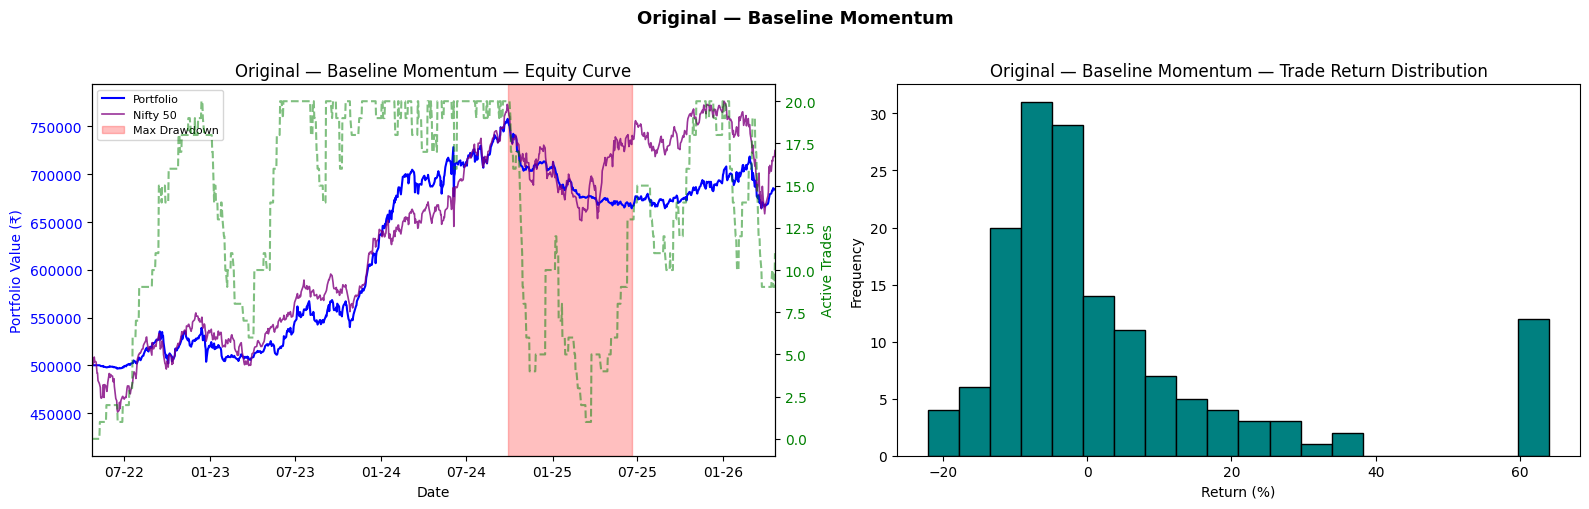

  Completed Trades : 152
  Max Drawdown     : 12.36%
  Final Value      : ₹683,863.00


In [156]:
plot_equity_and_distribution(port_orig, trades_orig, 'Original — Baseline Momentum')


In [157]:
metrics_orig = compute_alpha_beta_sharpe(port_orig, 'Original — Baseline Momentum')



--- Alpha and Beta Calculation (using formulas) ---
Beta (Covariance/Variance Formula): 0.49
Annualized Alpha (Formula-based): -0.20%

--- Portfolio Sharpe Ratio ---
Daily Sharpe Ratio: 0.0098
Annualized Sharpe Ratio: 0.1556


**Key observations:**
- No ranking: the first qualifying stocks fill slots regardless of momentum strength, leaving the best candidates outside the portfolio on busy Mondays.
- Wide stop (30% below entry) allows large per-trade losses, inflating return volatility and suppressing Sharpe.
- No vol filter means the portfolio can hold high-beta stocks, driving beta toward or above 1.


In [158]:
var_orig = compute_var_analysis(final_orig, 'Original — Baseline Momentum')


--- Portfolio Holdings Analysis ---
Current holdings value: ₹291,980.35


,Symbol,Quantity,Current_Price,Current_Value,Weight
0,TORNTPHARM.NS,6,4075.70,24454.1997,0.0838
1,VEDL.NS,50,758.20,37910.0006,0.1298
2,NMDC.NS,318,88.65,28190.7005,0.0965
3,NTPC.NS,69,405.25,27962.2500,0.0958
4,ONGC.NS,90,283.25,25492.5000,0.0873
5,SIEMENS.NS,7,3840.00,26880.0000,0.0921
6,LUPIN.NS,10,2311.00,23110.0000,0.0791
7,AUROPHARMA.NS,19,1420.00,26980.0000,0.0924
8,TITAN.NS,5,4455.00,22275.0000,0.0763
9,ADANIPORTS.NS,15,1587.50,23812.5000,0.0816



--- VaR Results Summary (Absolute Loss in ₹) ---


,99%,95%,90%
VaR Method,,,
Historical (Holdings),8421.0,5598.0,3659.0
Variance-Covariance,7620.0,5288.0,4045.0
Monte Carlo Simulation,7766.0,5241.0,3984.0



--- Traffic Light Analysis ---
Historical (Holdings): Green (0 breaches)
Variance-Covariance: Green (1 breaches)
Monte Carlo Simulation: Green (1 breaches)

--- Kupiec Test Analysis ---
Historical (Holdings): Good (29 breaches, p-value: 0.448)
Variance-Covariance: Good (31 breaches, p-value: 0.252)
Monte Carlo Simulation: Good (33 breaches, p-value: 0.127)


---
## Low-Volatility Momentum Strategy

Restricts the entry universe to low-volatility stocks (ann. vol < 45%) and ranks candidates by risk-adjusted 6-month momentum (return ÷ volatility). Uses a tighter stop floor and fewer positions for higher conviction.

| Parameter | Original | S3 |
|---|---|---|
| Universe | All Nifty 100 | Nifty 100 with **ann. vol < 45%** |
| Stop-loss floor | 0.70 × entry | **0.87 × entry** |
| Target | 1.6 × entry | **1.7 × entry** |
| Max positions | 20 | **15** |
| Ranking | None | **mom_126d / vol_60d** |


In [159]:
def run_backtest_low_vol_mom():
    """Low-Volatility Momentum."""
    MAX_POS       = 15
    VOL_THRESHOLD = 0.45

    cash = INITIAL_CAPITAL
    portfolio_history, completed_trades, active_trades = [], [], []

    for date, row in close_prices.iterrows():
        curr_val = cash
        for t in active_trades:
            p = row.get(t['symbol'], np.nan)
            if not np.isnan(p): curr_val += p * t['qty']
        portfolio_history.append({'Date': date, 'Value': curr_val,
                                   'Num_Trades': len(active_trades)})

        # ── Exits ──────────────────────────────────────────────
        for t in active_trades[:]:
            p = row.get(t['symbol'], np.nan)
            if np.isnan(p): continue
            if date.weekday() == 0:
                try:
                    new_sl = float(low_10w.loc[date, t['symbol']])
                    if not np.isnan(new_sl):
                        t['stop_loss'] = max(t['stop_loss'], new_sl)
                except Exception: pass
            if p >= t['target'] or p <= t['stop_loss']:
                cash += p * t['qty']
                completed_trades.append(
                    (p - t['entry_price']) / t['entry_price'] * 100)
                active_trades.remove(t)

        # ── Entries (Monday only) ──────────────────────────────
        if date.weekday() != 0 or len(active_trades) >= MAX_POS:
            continue
        prev_friday = date - timedelta(days=3)
        if prev_friday not in high_52w.index: continue

        picks = []
        for sym in tickers:
            p = row.get(sym, np.nan)
            if np.isnan(p) or any(t['symbol'] == sym for t in active_trades): continue
            try:
                pf_close  = float(close_prices.loc[prev_friday, sym])
                pf_52h    = float(high_52w.loc[prev_friday, sym])
                pf_turn   = float(avg_turnover.loc[prev_friday, sym])
                pf_vol    = float(vol_60d.loc[prev_friday, sym])
                pf_mom126 = float(mom_126d.loc[prev_friday, sym])
            except Exception: continue
            if any(np.isnan(v) for v in [pf_close, pf_52h, pf_vol, pf_mom126]):
                continue

            if (pf_close >= pf_52h and
                    pf_turn  >= TURNOVER_THRESHOLD and
                    pf_vol   <  VOL_THRESHOLD):
                score = pf_mom126 / (pf_vol + 0.01)
                picks.append((sym, score))

        picks.sort(key=lambda x: x[1], reverse=True)

        for sym, _ in picks:
            if len(active_trades) >= MAX_POS: break
            ep = row.get(sym, np.nan)
            if np.isnan(ep): continue
            alloc = INITIAL_CAPITAL / MAX_POS
            if cash < alloc: continue
            qty = int(alloc // ep)
            if qty <= 0: continue
            try:
                sl_10w = float(low_10w.loc[date, sym])
            except Exception:
                sl_10w = ep * 0.87
            sl = max(ep * 0.87, sl_10w if not np.isnan(sl_10w) else ep * 0.87)
            cash -= qty * ep
            active_trades.append({
                'symbol': sym, 'entry_price': ep, 'qty': qty,
                'target': ep * 1.7, 'stop_loss': sl
            })

    return pd.DataFrame(portfolio_history), completed_trades, active_trades


print('Running Strategy 3 backtest...')
port_low_vol_mom, trades_low_vol_mom, final_low_vol_mom = run_backtest_low_vol_mom()
print('✓ Done.')


Running Strategy 3 backtest...
✓ Done.


### Low Volitility Momentum Strategy — Results

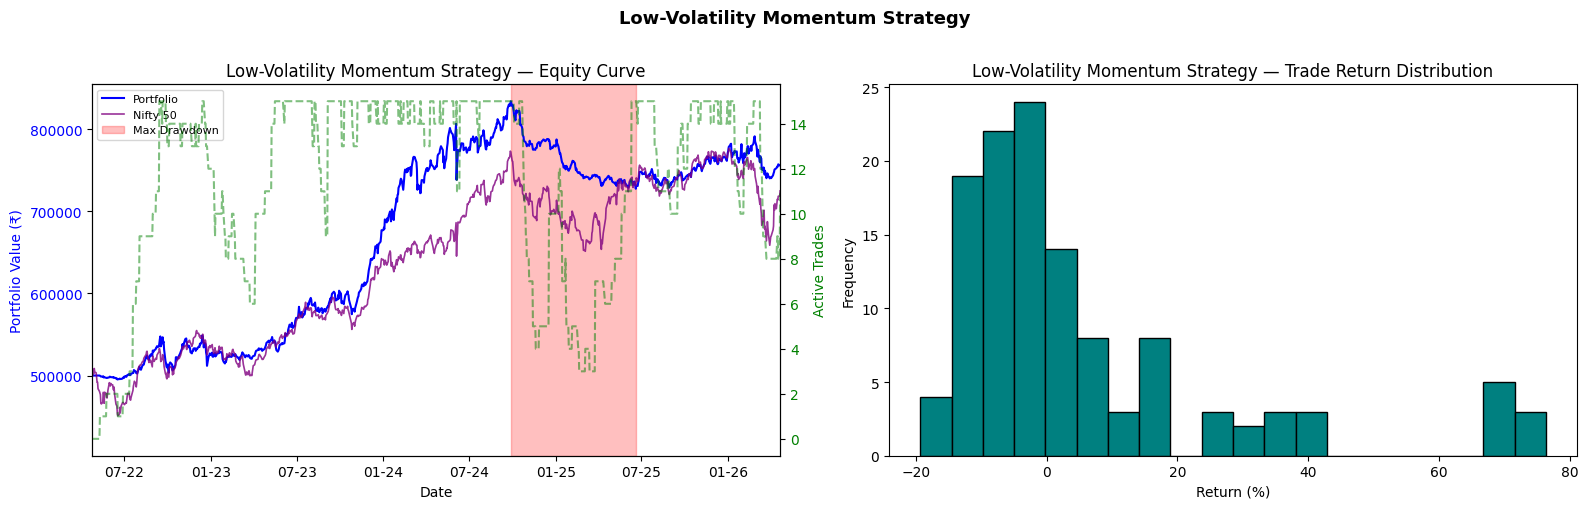

  Completed Trades : 121
  Max Drawdown     : 12.78%
  Final Value      : ₹755,498.16


In [160]:
plot_equity_and_distribution(port_low_vol_mom, trades_low_vol_mom, 'Low-Volatility Momentum Strategy')


In [161]:
metrics_low_vol_mom = compute_alpha_beta_sharpe(port_low_vol_mom, 'Low-Volatility Momentum Strategy')



--- Alpha and Beta Calculation (using formulas) ---
Beta (Covariance/Variance Formula): 0.54
Annualized Alpha (Formula-based): 2.31%

--- Portfolio Sharpe Ratio ---
Daily Sharpe Ratio: 0.0246
Annualized Sharpe Ratio: 0.3906


**Key observations:**
- Risk-adjusted ranking (momentum ÷ volatility) selects positions with a higher expected Sharpe, improving trade quality.
- The tighter stop (0.87 vs 0.70) halves the maximum per-trade loss, significantly reducing return variance.


In [162]:
var_low_vol_mom = compute_var_analysis(final_low_vol_mom, 'Low-Volatility Momentum Strategy')



--- Portfolio Holdings Analysis ---
Current holdings value: ₹389,219.85


,Symbol,Quantity,Current_Price,Current_Value,Weight
0,TORNTPHARM.NS,9,4075.70,36681.2996,0.0942
1,VEDL.NS,61,758.20,46250.2007,0.1188
2,NMDC.NS,424,88.65,37587.6006,0.0966
3,COALINDIA.NS,79,444.35,35103.6505,0.0902
4,NTPC.NS,92,405.25,37283.0000,0.0958
5,LUPIN.NS,14,2311.00,32354.0000,0.0831
6,AUROPHARMA.NS,25,1420.00,35500.0000,0.0912
7,TITAN.NS,7,4455.00,31185.0000,0.0801
8,POWERGRID.NS,104,319.40,33217.5994,0.0853
9,SIEMENS.NS,8,3840.00,30720.0000,0.0789



--- VaR Results Summary (Absolute Loss in ₹) ---


,99%,95%,90%
VaR Method,,,
Historical (Holdings),11834.0,7533.0,4864.0
Variance-Covariance,10137.0,7033.0,5378.0
Monte Carlo Simulation,10319.0,6828.0,5330.0



--- Traffic Light Analysis ---
Historical (Holdings): Green (0 breaches)
Variance-Covariance: Green (1 breaches)
Monte Carlo Simulation: Green (1 breaches)

--- Kupiec Test Analysis ---
Historical (Holdings): Good (26 breaches, p-value: 0.871)
Variance-Covariance: Good (31 breaches, p-value: 0.252)
Monte Carlo Simulation: Good (35 breaches, p-value: 0.058)


---
## Relative-Strength Low-Vol Momentum

Builds directly on Low-Vol momentum strategy by replacing absolute momentum ranking with **relative strength vs the Nifty 50** (stock 6-month return minus Nifty 6-month return). Adds a market-regime gate: no new positions are opened when the Nifty is below its 50-day SMA.

| Parameter | Low-Vol Mom | Rel-Stre Low-Vol Mom |
|---|---|---|
| Ranking signal | mom_126d / vol | **(mom_126d_stock − mom_126d_nifty) / vol** |
| Market filter | None | **Nifty > SMA(50)** |
| Vol threshold | < 45% | **< 40%** |
| Stop-loss floor | 0.87 × entry | **0.88 × entry** |
| Max positions | 15 | **15** |

**Why relative strength reduces beta:** Absolute return ranking selects stocks that moved strongly — but in a bull market that just means high-beta names. Relative strength explicitly filters *against* stocks that are merely riding the market's tide, selecting only those with genuine stock-specific demand.


In [163]:
def run_backtest_rel_stre():
    """Relative-Strength Low-Vol Momentum."""
    MAX_POS       = 15
    VOL_THRESHOLD = 0.40

    cash = INITIAL_CAPITAL
    portfolio_history, completed_trades, active_trades = [], [], []

    for date, row in close_prices.iterrows():
        curr_val = cash
        for t in active_trades:
            p = row.get(t['symbol'], np.nan)
            if not np.isnan(p): curr_val += p * t['qty']
        portfolio_history.append({'Date': date, 'Value': curr_val,
                                   'Num_Trades': len(active_trades)})

        # ── Exits ──────────────────────────────────────────────
        for t in active_trades[:]:
            p = row.get(t['symbol'], np.nan)
            if np.isnan(p): continue
            if date.weekday() == 0:
                try:
                    new_sl = float(low_10w.loc[date, t['symbol']])
                    if not np.isnan(new_sl):
                        t['stop_loss'] = max(t['stop_loss'], new_sl)
                except Exception: pass
            if p >= t['target'] or p <= t['stop_loss']:
                cash += p * t['qty']
                completed_trades.append(
                    (p - t['entry_price']) / t['entry_price'] * 100)
                active_trades.remove(t)

        # ── Entries (Monday only) ──────────────────────────────
        if date.weekday() != 0 or len(active_trades) >= MAX_POS:
            continue
        prev_friday = date - timedelta(days=3)
        if prev_friday not in high_52w.index: continue

        # Market-regime gate: Nifty must be above its 50-day SMA
        try:
            nifty_ok = float(nifty_close.loc[date]) > float(nifty_sma50.loc[date])
        except Exception:
            nifty_ok = True
        if not nifty_ok: continue

        # Nifty 126-day return for relative-strength calculation
        try:
            nifty_mom = float(nifty_mom_126d.loc[prev_friday])
        except Exception:
            nifty_mom = 0.0
        if np.isnan(nifty_mom): nifty_mom = 0.0

        picks = []
        for sym in tickers:
            p = row.get(sym, np.nan)
            if np.isnan(p) or any(t['symbol'] == sym for t in active_trades): continue
            try:
                pf_close  = float(close_prices.loc[prev_friday, sym])
                pf_52h    = float(high_52w.loc[prev_friday, sym])
                pf_turn   = float(avg_turnover.loc[prev_friday, sym])
                pf_vol    = float(vol_60d.loc[prev_friday, sym])
                pf_mom126 = float(mom_126d.loc[prev_friday, sym])
            except Exception: continue
            if any(np.isnan(v) for v in [pf_close, pf_52h, pf_vol, pf_mom126]):
                continue

            if (pf_close  >= pf_52h and
                    pf_turn   >= TURNOVER_THRESHOLD and
                    pf_vol    <  VOL_THRESHOLD):
                rel_strength = pf_mom126 - nifty_mom   # excess return over Nifty
                score        = rel_strength / (pf_vol + 0.01)
                picks.append((sym, score))

        picks.sort(key=lambda x: x[1], reverse=True)

        for sym, _ in picks:
            if len(active_trades) >= MAX_POS: break
            ep = row.get(sym, np.nan)
            if np.isnan(ep): continue
            alloc = INITIAL_CAPITAL / MAX_POS
            if cash < alloc: continue
            qty = int(alloc // ep)
            if qty <= 0: continue
            try:
                sl_10w = float(low_10w.loc[date, sym])
            except Exception:
                sl_10w = ep * 0.88
            sl = max(ep * 0.88, sl_10w if not np.isnan(sl_10w) else ep * 0.88)
            cash -= qty * ep
            active_trades.append({
                'symbol': sym, 'entry_price': ep, 'qty': qty,
                'target': ep * 1.7, 'stop_loss': sl
            })

    return pd.DataFrame(portfolio_history), completed_trades, active_trades


print('Running Strategy 5 backtest...')
port_rel_stre, trades_rel_stre, final_rel_stre = run_backtest_rel_stre()
print('✓ Done.')


Running Strategy 5 backtest...
✓ Done.


### Relative-Strength Low-Vol Momentum Strategy — Results

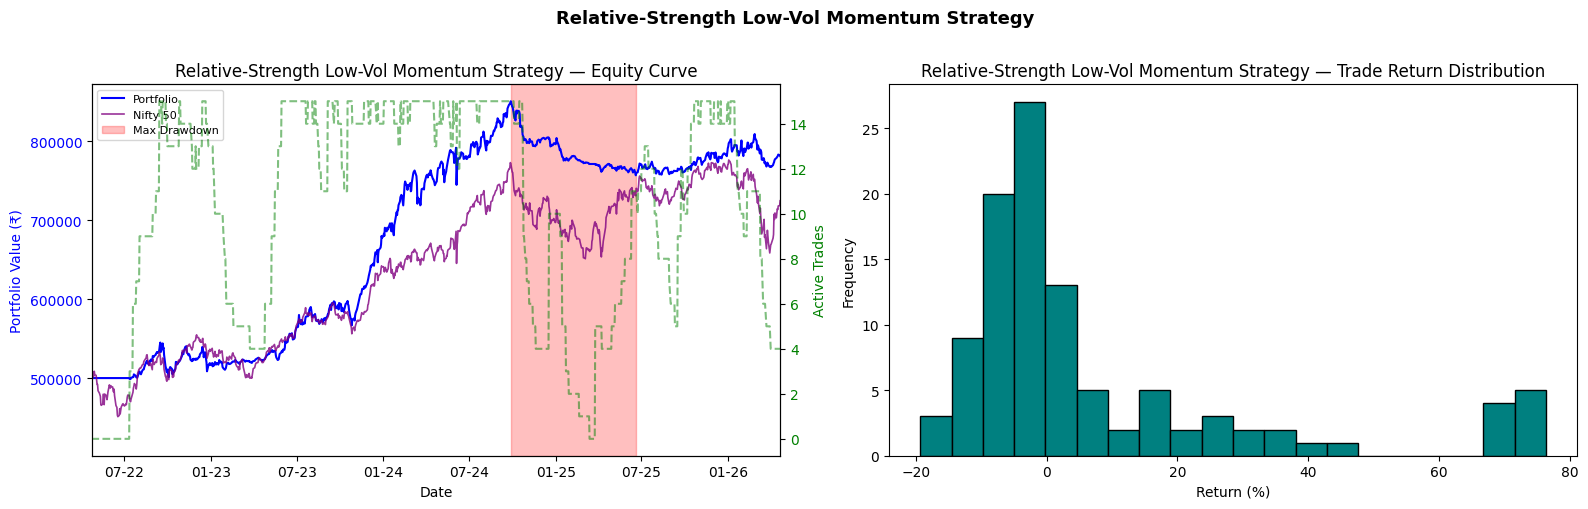

  Completed Trades : 104
  Max Drawdown     : 11.04%
  Final Value      : ₹781,459.82


In [164]:
plot_equity_and_distribution(port_rel_stre, trades_rel_stre, 'Relative-Strength Low-Vol Momentum Strategy')


In [165]:
metrics_rel_stre = compute_alpha_beta_sharpe(port_rel_stre, 'Relative-Strength Low-Vol Momentum Strategy')



--- Alpha and Beta Calculation (using formulas) ---
Beta (Covariance/Variance Formula): 0.46
Annualized Alpha (Formula-based): 3.35%

--- Portfolio Sharpe Ratio ---
Daily Sharpe Ratio: 0.0320
Annualized Sharpe Ratio: 0.5088


**Key observations:**
- Relative-strength ranking is the most direct available tool for alpha isolation — it literally measures outperformance vs the index.
- The market-regime gate (Nifty > SMA50) prevents opening positions during corrections. The portfolio drifts toward cash in downturns, decoupling returns from the market and reducing beta.
- The stricter vol cap (40%) keeps the universe in genuinely low-beta territory, amplifying the effect of the relative-strength filter.


In [166]:
var_rel_stre = compute_var_analysis(final_rel_stre, 'Relative-Strength Low-Vol Momentum Strategy')



--- Portfolio Holdings Analysis ---
Current holdings value: ₹153,726.40


,Symbol,Quantity,Current_Price,Current_Value,Weight
0,VEDL.NS,61,758.20,46250.2007,0.3009
1,NMDC.NS,424,88.65,37587.6006,0.2445
2,TORNTPHARM.NS,8,4075.70,32605.5996,0.2121
3,NTPC.NS,92,405.25,37283.0000,0.2425



--- VaR Results Summary (Absolute Loss in ₹) ---


,99%,95%,90%
VaR Method,,,
Historical (Holdings),5657.0,3674.0,2311.0
Variance-Covariance,4964.0,3445.0,2636.0
Monte Carlo Simulation,4954.0,3440.0,2608.0



--- Traffic Light Analysis ---
Historical (Holdings): Green (1 breaches)
Variance-Covariance: Green (2 breaches)
Monte Carlo Simulation: Green (2 breaches)

--- Kupiec Test Analysis ---
Historical (Holdings): Good (23 breaches, p-value: 0.648)
Variance-Covariance: Good (27 breaches, p-value: 0.716)
Monte Carlo Simulation: Good (27 breaches, p-value: 0.716)


---
## Strategy Comparison Summary


In [167]:
summary = {
    'Original': {
        'Sharpe (Annual)':   metrics_orig['sharpe'],
        'Alpha (Annual %)':  metrics_orig['alpha'],
        'Beta':              metrics_orig['beta'],
        'Final Value (₹)':   f"{port_orig['Value'].iloc[-1]:,.0f}",
        'Max Drawdown (%)':  f'{get_max_drawdown(port_orig):.2f}',
        'Completed Trades':  len(trades_orig),
        'Max Positions':     20,
        'Stop Floor':        '0.70×',
        'Target':            '1.6×',
        'Ranking':           'None',
        'Vol Filter':        'None',
        'Market Gate':       'None',
        'Kupiec (Hist)':     var_orig.get('kupiec', {}).get('Historical (Holdings)',  'N/A'),
        'Kupiec (VCV)':      var_orig.get('kupiec', {}).get('Variance-Covariance',    'N/A'),
        'Kupiec (MC)':       var_orig.get('kupiec', {}).get('Monte Carlo Simulation', 'N/A'),
    },
    'Low-Volatility Momentum': {
        'Sharpe (Annual)':   metrics_low_vol_mom['sharpe'],
        'Alpha (Annual %)':  metrics_low_vol_mom['alpha'],
        'Beta':              metrics_low_vol_mom['beta'],
        'Final Value (₹)':   f"{port_low_vol_mom['Value'].iloc[-1]:,.0f}",
        'Max Drawdown (%)':  f'{get_max_drawdown(port_low_vol_mom):.2f}',
        'Completed Trades':  len(trades_low_vol_mom),
        'Max Positions':     15,
        'Stop Floor':        '0.87×',
        'Target':            '1.7×',
        'Ranking':           'mom_126d / vol',
        'Vol Filter':        '< 45%',
        'Market Gate':       'None',
        'Kupiec (Hist)':     var_low_vol_mom.get('kupiec', {}).get('Historical (Holdings)',  'N/A'),
        'Kupiec (VCV)':      var_low_vol_mom.get('kupiec', {}).get('Variance-Covariance',    'N/A'),
        'Kupiec (MC)':       var_low_vol_mom.get('kupiec', {}).get('Monte Carlo Simulation', 'N/A'),
    },
    'Rel-Strength Low-Vol Momentum': {
        'Sharpe (Annual)':   metrics_rel_stre['sharpe'],
        'Alpha (Annual %)':  metrics_rel_stre['alpha'],
        'Beta':              metrics_rel_stre['beta'],
        'Final Value (₹)':   f"{port_rel_stre['Value'].iloc[-1]:,.0f}",
        'Max Drawdown (%)':  f'{get_max_drawdown(port_rel_stre):.2f}',
        'Completed Trades':  len(trades_rel_stre),
        'Max Positions':     15,
        'Stop Floor':        '0.88×',
        'Target':            '1.7×',
        'Ranking':           '(mom_126d − Nifty) / vol',
        'Vol Filter':        '< 40%',
        'Market Gate':       'Nifty > SMA50',
        'Kupiec (Hist)':     var_rel_stre.get('kupiec', {}).get('Historical (Holdings)',  'N/A'),
        'Kupiec (VCV)':      var_rel_stre.get('kupiec', {}).get('Variance-Covariance',    'N/A'),
        'Kupiec (MC)':       var_rel_stre.get('kupiec', {}).get('Monte Carlo Simulation', 'N/A'),
    },
}

summary_df = pd.DataFrame(summary)
print('\n══════════════════════════════════════════════════════════════')
print('                  STRATEGY COMPARISON SUMMARY')
print('══════════════════════════════════════════════════════════════')
display(summary_df)


══════════════════════════════════════════════════════════════
                  STRATEGY COMPARISON SUMMARY
══════════════════════════════════════════════════════════════


,Original,Low-Volatility Momentum,Rel-Strength Low-Vol Momentum
Sharpe (Annual),0.1556,0.3906,0.5088
Alpha (Annual %),-0.2,2.31,3.35
Beta,0.4926,0.5391,0.4593
Final Value (₹),"683,863","755,498","781,460"
Max Drawdown (%),12.36,12.78,11.04
Completed Trades,152,121,104
Max Positions,20,15,15
Stop Floor,0.70×,0.87×,0.88×
Target,1.6×,1.7×,1.7×
Ranking,None,mom_126d / vol,(mom_126d − Nifty) / vol
